<a href="https://colab.research.google.com/github/Sagar122198/ML/blob/main/Decision%20tree_ML%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Data handling**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load the data
df = pd.read_csv('student_placement.csv')

In [3]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (100000, 26)

First 5 rows:


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


## Data Preprocessing

In [4]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

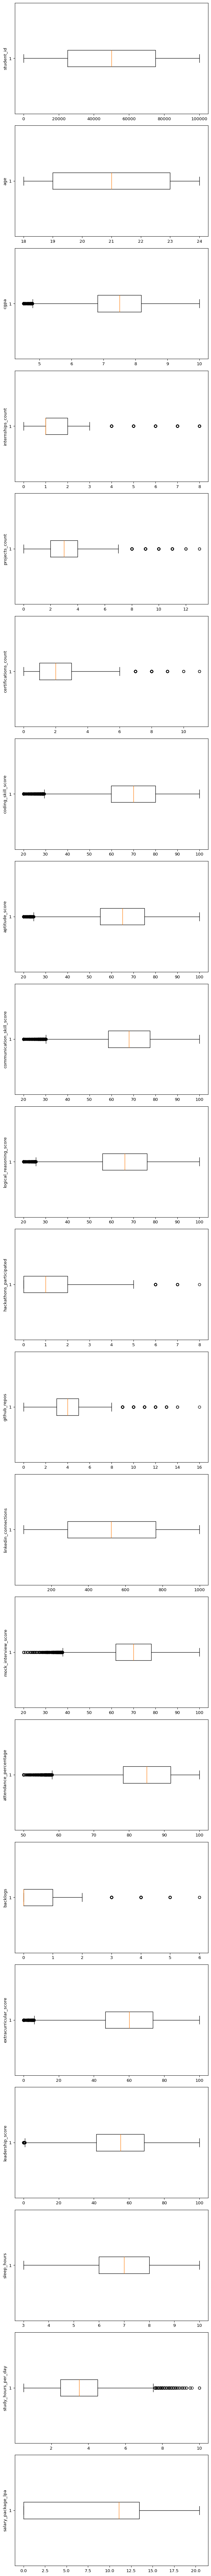

In [6]:
#Statistical Summary and Visualizing Outliers

df.describe()

numeric_cols = df.select_dtypes(include=np.number).columns

fig, axs = plt.subplots(len(numeric_cols), 1, figsize=(7, 4 * len(numeric_cols)), dpi=95)

# Adjust subplot creation for a single numeric column to avoid an error trying to index a single Axes object
if len(numeric_cols) == 1:
    axs = [axs] # Make axs iterable if there's only one subplot

for i, col in enumerate(numeric_cols):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [8]:
#Remove Outliers Using the Interquartile Range (IQR) Method

# Replace 'Insulin' with a valid numeric column from your DataFrame, e.g., 'salary_package_lpa'
column_to_clean = 'salary_package_lpa'

q1, q3 = np.percentile(df[column_to_clean], [25, 75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
clean_df = df[(df[column_to_clean] >= lower) & (df[column_to_clean] <= upper)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape after removing outliers from {column_to_clean}: {clean_df.shape}")

Original DataFrame shape: (100000, 26)
Cleaned DataFrame shape after removing outliers from salary_package_lpa: (100000, 26)


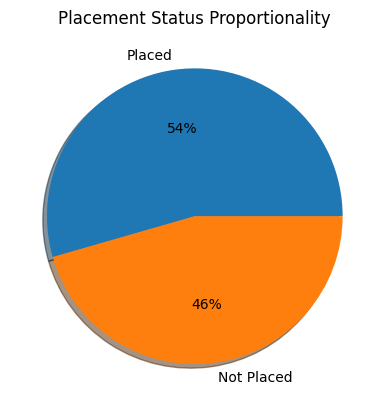

In [12]:
#Visualize Target Variable Distribution

plt.pie(df['placement_status'].value_counts(), labels=df['placement_status'].value_counts().index, autopct='%.f%%', shadow=True)
plt.title('Placement Status Proportionality')
plt.show()

In [13]:
#Prepare independent variables (features) and dependent variable (target) separately for modeling.

X = df.drop(columns=['placement_status'])
y = df['placement_status']

In [14]:
df = df.dropna()

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [17]:
X = df.drop('placement_status', axis=1)  # target column name change if needed
y = df['placement_status']

## Model Training & Hyperparameter Tuning

In [19]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
#X → input features
#y → target (what you want to predict)
#test_size=0.2 → 20% data for testing
#X_train, y_train → used to train model

In [20]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
#DecisionTreeClassifier() → creates the model
#fit() → model learns patterns from data

DecisionTreeClassifier()

In [27]:
DecisionTreeClassifier(max_depth=5, min_samples_split=5)

DecisionTreeClassifier(max_depth=5, min_samples_split=5)

In [36]:
tuned_acc = best_model.score(X_test, y_test)
print("Tuned Model Accuracy:", tuned_acc)

Tuned Model Accuracy: 1.0


In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

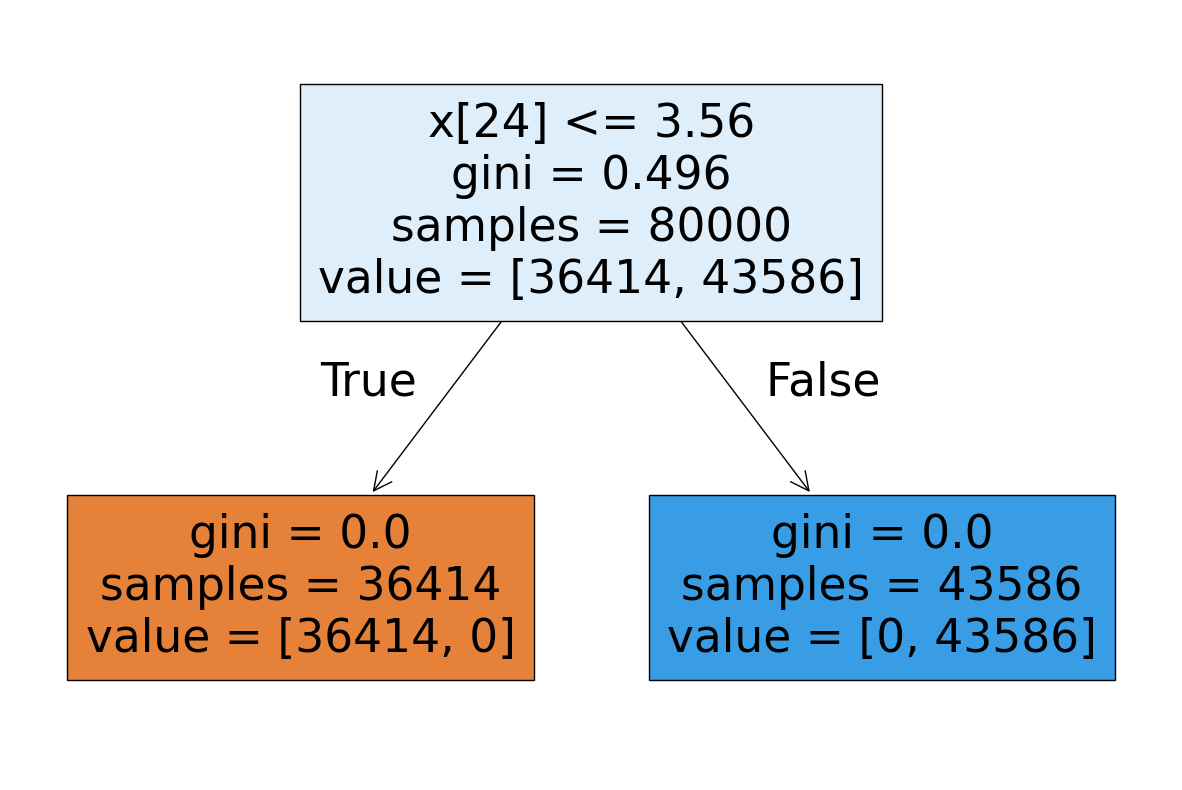

In [30]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(best_model, filled=True)
plt.show()

## **Predictions**

In [45]:
sample = [[
    7.5,   # CGPA
    3,     # Internships
    5,     # Projects
    2,     # Workshops
    4,     # Hackathons
    1,     # Certifications
    0,     # Backlogs
    8.0,   # Communication Skills
    7.5,   # Technical Skills
    1,     # Extra Activities
    0,     # Gap Year
    1,     # Leadership
    7.0,   # Aptitude Score
    8.2,   # Coding Score
    1,     # Teamwork
    0,     # Part-time Job
    1,     # Research Work
    7.8,   # Academic Performance
    6.5,   # Problem Solving
    1,     # Club Participation
    0,     # Sports
    1,     # Online Courses
    8.5,   # Interview Score
    1,     # Resume Quality
    0      # Discipline Issues
]]

pred = best_model.predict(sample)

print("Placed" if pred[0] == 1 else "Not Placed")

Not Placed


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [46]:
sample = [[
    8.8,   # CGPA (high)
    4,     # Internships
    6,     # Projects
    3,     # Workshops
    5,     # Hackathons
    2,     # Certifications
    0,     # Backlogs
    9.0,   # Communication Skills
    8.5,   # Technical Skills
    1,     # Extra Activities
    0,     # Gap Year
    1,     # Leadership
    8.5,   # Aptitude Score
    9.0,   # Coding Score
    1,     # Teamwork
    0,     # Part-time Job
    1,     # Research Work
    8.7,   # Academic Performance
    8.0,   # Problem Solving
    1,     # Club Participation
    1,     # Sports
    2,     # Online Courses
    9.2,   # Interview Score
    1,     # Resume Quality
    5      # 🔥 Important feature (must be > 3.56 based on your tree)
]]

pred = best_model.predict(sample)

print("Placed" if pred[0] == 1 else "Not Placed")

Placed


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
